# Notebook overview

- Goal: Train and evaluate a neural network to predict customer churn from customer_churn.csv.
- Steps: imports → load data → clean/encode/scale → train/test split → build & train model → predict → evaluate (accuracy, confusion matrix, classification report, heatmap).

## Cell structure

- Cell 1: import pandas, numpy  
- Cell 2: import train_test_split, LabelEncoder, StandardScaler from sklearn  
- Cell 3: import accuracy_score, confusion_matrix, classification_report  
- Cell 4: import Sequential, Dense from tensorflow.keras  
- Cell 5: import print_heatmap from utils  
- Cell 6: load dataframe from "customer_churn.csv"  
- Cell 7: display df.head()  
- Cell 8: drop "customerID" column  
- Cell 9: convert "TotalCharges" to numeric (coerce)  
- Cell 10: fill missing "TotalCharges" with median  
- Cell 11: create LabelEncoder instance  
- Cell 12: encode object dtype columns with LabelEncoder  
- Cell 13: define X = df.drop("Churn", axis=1)  
- Cell 14: define y = df["Churn"]  
- Cell 15: create StandardScaler instance  
- Cell 16: scale X with scaler.fit_transform  
- Cell 17: split into X_train, X_test, y_train, y_test (test_size=0.2, random_state=42)  
- Cell 18: initialize Sequential model  
- Cell 19: add Dense(32, input_dim=..., activation="relu")  
- Cell 20: add Dense(16, activation="relu")  
- Cell 21: add Dense(1, activation="sigmoid")  
- Cell 22: compile model (adam, binary_crossentropy, metrics=["accuracy"])  
- Cell 23: fit model (epochs=50, batch_size=32, validation_split=0.2)  
- Cell 24: predict on X_test  
- Cell 25: threshold predictions to binary (pred > 0.5)  
- Cell 26: compute accuracy_score  
- Cell 27: print accuracy  
- Cell 28: compute confusion_matrix  
- Cell 29: plot confusion heatmap via print_heatmap  
- Cell 30: print confusion matrix  
- Cell 31: print classification report

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from tensorflow.keras.models import Sequential # type:ignore
from tensorflow.keras.layers import Dense # type:ignore

In [ ]:
from utils import print_heatmap

In [ ]:
df = pd.read_csv("customer_churn.csv")

In [ ]:
df.head()

In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],
                                   errors="coerce")

In [ ]:
df["TotalCharges"].fillna(df["TotalCharges"].median(),
                          inplace=True)

In [ ]:
encoder = LabelEncoder()

In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

In [ ]:
X = df.drop("Churn", axis=1)

In [ ]:
y = df["Churn"]

In [ ]:
scaler = StandardScaler()

In [ ]:
X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(32,
                input_dim=X_train.shape[1],
                activation="relu"))

In [ ]:
model.add(Dense(16,
                activation="relu"))

In [ ]:
model.add(Dense(1,
                activation="sigmoid"))

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

In [ ]:
pred = model.predict(X_test)

In [ ]:
pred = (pred > 0.5).astype(int)

In [ ]:
acc = accuracy_score(y_test, pred)

In [ ]:
print("Accuracy:", acc)

In [ ]:
cm = confusion_matrix(y_test, pred)

In [ ]:
print_heatmap(y_test, pred)

In [ ]:
print(cm)

In [ ]:
print(classification_report(y_test,pred))

![Screenshot 2026-07-12 122408.png](<attachment:Screenshot 2026-07-12 122408.png>)
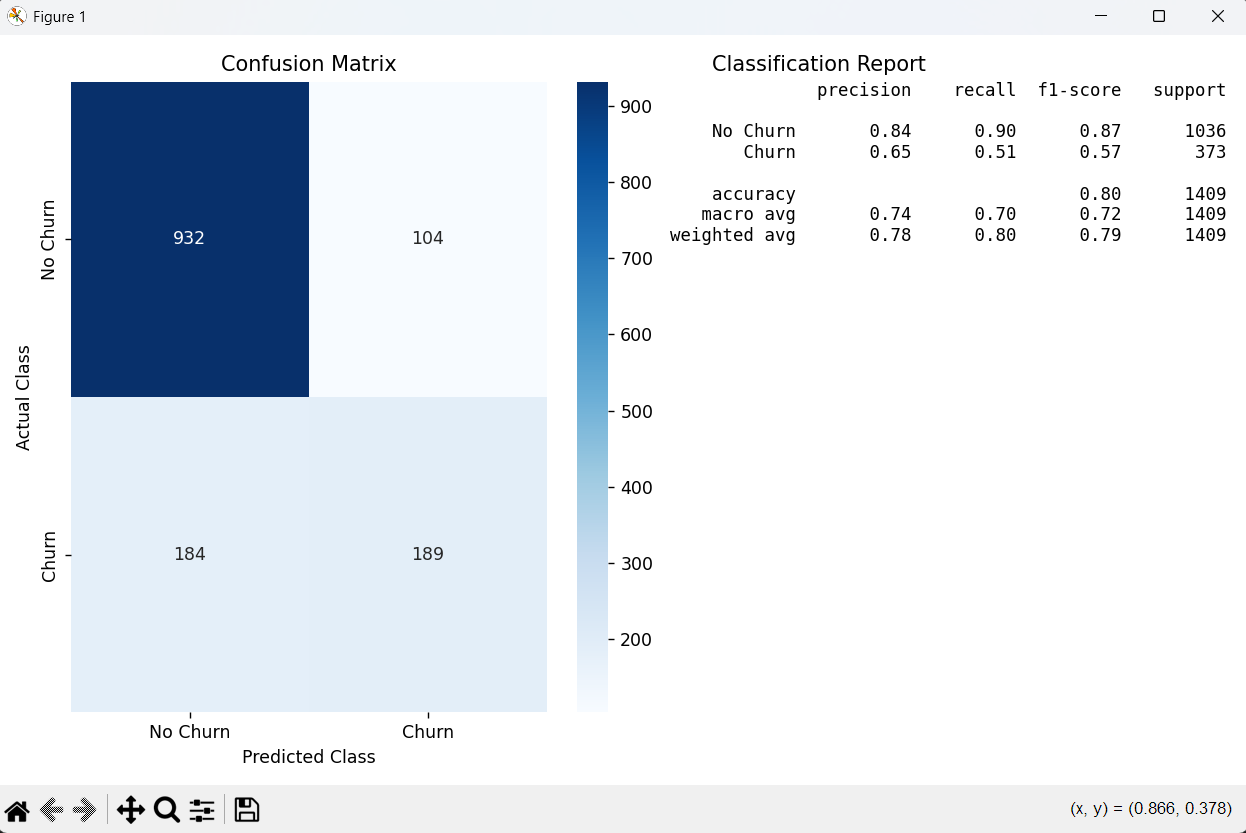